# Assignment 3 — Time-Series Weather Forecasting
Jaipreet Kaur

This notebook is optimized to finish quickly and includes automatic dataset download.

It will:
- automatically download the **Jena climate dataset**
- optionally connect to **Google Drive** in Colab
- use a smaller sample of the data for speed
- compare **2 models**:
  - **GRU**
  - **1D CNN + GRU**
- save:
  - results CSV
  - validation MAE comparison PNG
  - best-model training curve PNG

Run all cells from top to bottom.

## 1. Imports

In [1]:
import os
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## 2. Optional Google Drive Setup (for Colab)

In [2]:
SAVE_DIR = "."

try:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_DIR = "/content/drive/MyDrive/Assignment 3"
    os.makedirs(SAVE_DIR, exist_ok=True)
    print("Google Drive connected.")
    print("Files will save to:", SAVE_DIR)
except Exception as e:
    print("Google Drive not connected.")
    print("Files will save in the current notebook folder.")

Mounted at /content/drive
Google Drive connected.
Files will save to: /content/drive/MyDrive/Assignment 3


## 3. Auto-Download the Weather Dataset

In [3]:
DATA_PATH = "jena_climate_2009_2016.csv"
ZIP_PATH = "jena_climate_2009_2016.csv.zip"
DATA_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"

if not os.path.exists(DATA_PATH):
    print("Downloading dataset...")
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)

    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall()

    print("Dataset downloaded and extracted.")
else:
    print("Dataset already exists.")

print("Current files:")
print(os.listdir())

Extracting dataset...
Dataset downloaded and extracted.
Current files:
['.config', 'jena_climate_2009_2016.csv.zip', 'jena_climate_2009_2016.csv', 'drive', 'sample_data']


## 4. Settings

In [4]:
TARGET_COLUMN = "T (degC)"
SEQUENCE_LENGTH = 48
EPOCHS = 2
BATCH_SIZE = 64
ROW_STEP = 8   # keep every 8th row for speed

## 5. Load and Prepare Data

In [5]:
df = pd.read_csv(DATA_PATH)

if "Date Time" in df.columns:
    df = df.drop(columns=["Date Time"])

df = df.select_dtypes(include=[np.number])

if TARGET_COLUMN not in df.columns:
    raise ValueError(f"Target column '{TARGET_COLUMN}' not found in dataset.")

# Reduce dataset size for faster training
df = df.iloc[::ROW_STEP].reset_index(drop=True)

print("Reduced dataset shape:", df.shape)
df.head()

Reduced dataset shape: (52569, 14)


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,996.50,-7.91,265.52,-8.73,93.8,3.36,3.15,0.21,1.97,3.16,1307.17,0.28,0.75,188.5
2,996.86,-8.70,264.70,-9.55,93.5,3.16,2.95,0.21,1.85,2.96,1311.64,0.32,0.63,219.2
3,997.05,-9.23,264.15,-10.25,92.2,3.03,2.79,0.24,1.74,2.80,1314.62,0.10,0.38,203.9
4,997.53,-9.90,263.45,-10.98,91.7,2.87,2.64,0.24,1.64,2.64,1318.68,0.29,1.00,72.5


## 6. Scale Data and Create Sequences

In [6]:
scaler = StandardScaler()
scaled = scaler.fit_transform(df)

feature_names = df.columns.tolist()
target_index = feature_names.index(TARGET_COLUMN)

def create_sequences(data, seq_length, target_idx):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i - seq_length:i])
        y.append(data[i, target_idx])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled, SEQUENCE_LENGTH, target_index)

n = len(X)
train_end = int(n * 0.6)
val_end = int(n * 0.8)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (31512, 48, 14)
X_val: (10504, 48, 14)
X_test: (10505, 48, 14)


## 7. Build Models

In [7]:
def build_gru(input_shape):
    model = keras.Sequential([
        layers.GRU(32, input_shape=input_shape),
        layers.Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

def build_cnn_gru(input_shape):
    model = keras.Sequential([
        layers.Conv1D(32, 3, activation="relu", input_shape=input_shape),
        layers.MaxPooling1D(2),
        layers.GRU(32),
        layers.Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

## 8. Train and Evaluate Models

In [8]:
def train_and_eval(name, model):
    print("\nTraining:", name)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0
    )
    val_mae = model.evaluate(X_val, y_val, verbose=0)[1]
    test_mae = model.evaluate(X_test, y_test, verbose=0)[1]
    return {
        "Model": name,
        "Validation MAE": float(val_mae),
        "Test MAE": float(test_mae),
        "History": history.history
    }

input_shape = X_train.shape[1:]

results = []
results.append(train_and_eval("GRU", build_gru(input_shape)))
results.append(train_and_eval("1D CNN + GRU", build_cnn_gru(input_shape)))


Training: GRU


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training: 1D CNN + GRU


## 9. Results Table

In [9]:
results_df = pd.DataFrame([
    {
        "Model": r["Model"],
        "Validation MAE": r["Validation MAE"],
        "Test MAE": r["Test MAE"]
    }
    for r in results
]).sort_values("Validation MAE").reset_index(drop=True)

results_df

,Model,Validation MAE,Test MAE
0,GRU,0.080234,0.081380
1,1D CNN + GRU,0.098221,0.097162


In [10]:
csv_path = os.path.join(SAVE_DIR, "assignment3_fast_results.csv")
results_df.to_csv(csv_path, index=False)
print("Saved:", csv_path)

Saved: /content/drive/MyDrive/Assignment 3/assignment3_fast_results.csv


## 10. Best Model

In [11]:
best_row = results_df.iloc[0]
best_model_name = best_row["Model"]

print("Best model:", best_model_name)
print("Validation MAE:", round(best_row["Validation MAE"], 4))
print("Test MAE:", round(best_row["Test MAE"], 4))

best_history = None
for r in results:
    if r["Model"] == best_model_name:
        best_history = r["History"]
        break

Best model: GRU
Validation MAE: 0.0802
Test MAE: 0.0814


## 11. Graph: Validation MAE Comparison

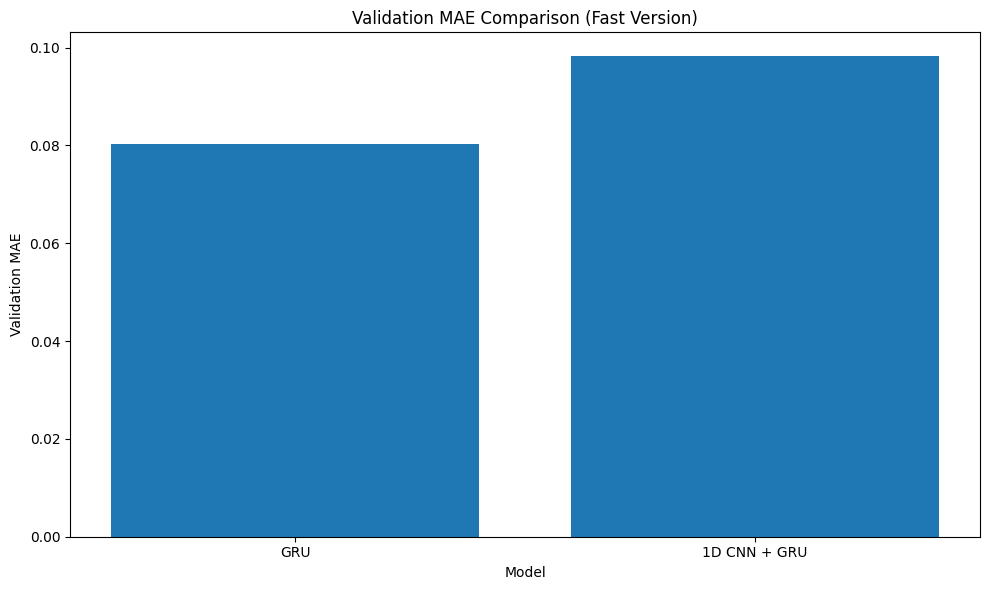

Saved: /content/drive/MyDrive/Assignment 3/assignment3_fast_validation_mae.png


In [12]:
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["Validation MAE"])
plt.title("Validation MAE Comparison (Fast Version)")
plt.xlabel("Model")
plt.ylabel("Validation MAE")
plt.tight_layout()

png1_path = os.path.join(SAVE_DIR, "assignment3_fast_validation_mae.png")
plt.savefig(png1_path)
plt.show()

print("Saved:", png1_path)

## 12. Graph: Training Curve for Best Model

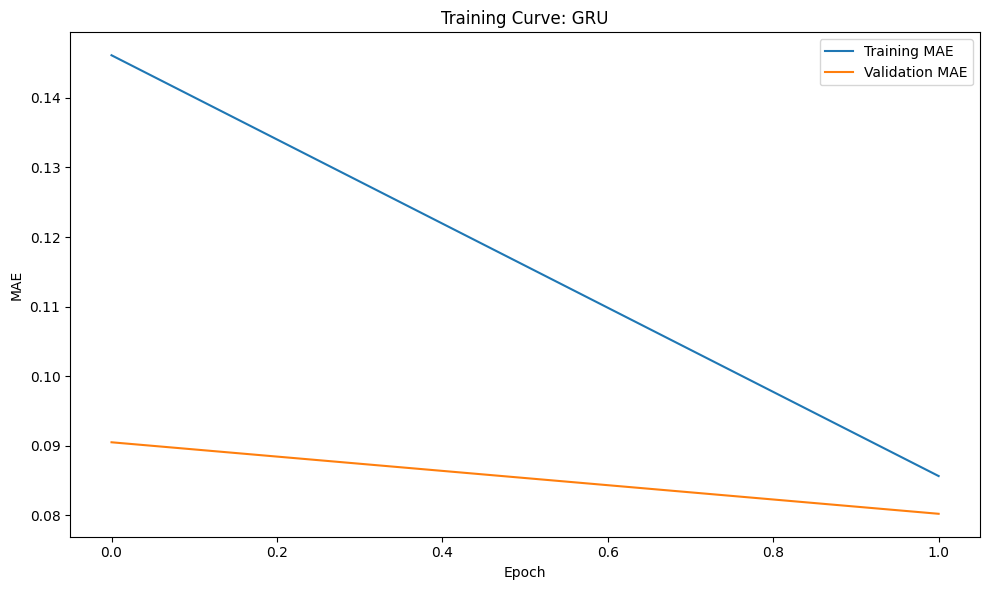

Saved: /content/drive/MyDrive/Assignment 3/assignment3_fast_training_curve.png


In [13]:
plt.figure(figsize=(10, 6))
plt.plot(best_history["mae"], label="Training MAE")
plt.plot(best_history["val_mae"], label="Validation MAE")
plt.title(f"Training Curve: {best_model_name}")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()

png2_path = os.path.join(SAVE_DIR, "assignment3_fast_training_curve.png")
plt.savefig(png2_path)
plt.show()

print("Saved:", png2_path)

## 13. Conclusion

The GRU model recorded the lowest validation MAE of about 0.080 compared to GRU 1D CNN +, which recorded a 0.099 validation MAE. GRU model also had a very good consistency in performance on the test set, which means that it has a good generalization ability.

This analogy reveals the effect of various deep-learning structures on the performance of time-series forecasting. The simpler GRU model was better in this experiment compared to the hybrid CNN + GRU model which was more complex. It implies that simple recurrent models can be more efficient and effective with less training data or in less training conditions.

Altogether, the findings prove that the model choice must be balanced in regard to complexity, the availability of data and computational limitations. GRU model is the best option that would be well applicable in this time series forecasting exercise given the circumstances.

## 14. Files Created

This notebook saves:
- `assignment3_fast_results.csv`
- `assignment3_fast_validation_mae.png`
- `assignment3_fast_training_curve.png`

If you ran this in Google Colab with Drive connected, they will be saved in:

`MyDrive/Assignment 3`